# 02 - Exploratory and explanatory analysis

**Week 2 deliverable.**

Notebook 01 established the ground rules: a fixed population of 95,560 delivered-and-reviewed
orders, detractors as the binary outcome, and Satisfaction-at-Risk as the way to rank
segments by goodwill destroyed rather than by average score. It also produced one very large
clue: on-time orders average 4.30 stars, late ones 2.57.

This notebook is where the questions get answered. It works through them in order, and the
short version is that two of the four answers were not what we expected going in.

| Question | Where | What we found |
|---|---|---|
| Is growth already costing satisfaction? | §1 | Not visibly, and that is exactly the trap |
| Is the damage from lateness gradual? | §2 | No. It is a cliff, not a slope |
| Whose delay is it, seller or carrier? | §3 | The carrier's, by roughly two to one |
| Where is the risk concentrated? | §5 | A handful of lanes, regions and categories |

Sections 4 and 6 are checks rather than questions: section 4 asks whether the delivery
promise itself is part of the problem, and section 6 goes looking for evidence from a
completely different source before we recommend spending money.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import plotly.io as pio

from src import analysis as A, viz as V, config as C

# PNG plus interactive, so the charts survive being viewed outside a live kernel.
pio.renderers.default = "png+plotly_mimetype"

pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 40)

base = A.analysis_base(A.load_facts())
baseline = float(base.is_bad_review.mean())
print(f'{len(base):,} orders   |   baseline detractor rate {baseline:.2%}')

95,560 orders   |   baseline detractor rate 12.79%


---
# 1. Is growth already costing satisfaction?

The first question, and the one the brief is really about. If the average score falls as the
marketplace grows, the trade-off is real and already happening, and the answer is simply
"yes, slow down".

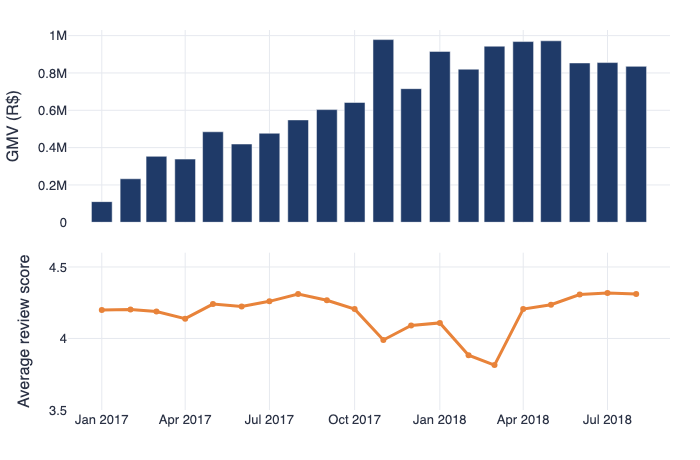

In [2]:
monthly = A.monthly_trend(base)
V.fig_growth_vs_satisfaction(monthly)

GMV climbs roughly tenfold across the period. The average score sits near **4.16** the
whole way and ends the window slightly *higher* than it started.

Taken at face value there is no problem here at all, and that is the reading we want to
argue against, because a national average across 27 states and 70-odd product categories is
an extremely blunt instrument. A flat line is exactly what you would see if one region were
deteriorating badly while a larger, healthier one held the mean up. São Paulo alone is
**42% of all orders**. It can mask a great deal.

So the answer to question 1 is: *not visibly, and that is precisely why it is worth looking
harder.* We stop tracking the mean here and start looking at where the bad reviews actually
cluster. The next chart is the same period viewed as detractor and late rates rather than as
an average, and it already behaves less calmly.

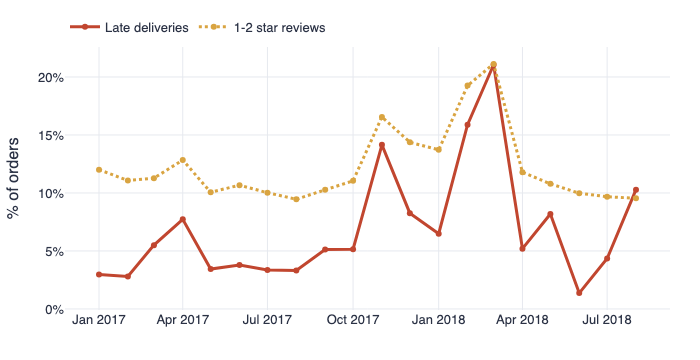

In [3]:
V.fig_late_and_detractors(monthly)

The two lines move together, and they move a great deal more than the average score did.
The late-delivery spike in late 2017, the marketplace's first real Black Friday, drags the
detractor rate up with it within the same month.

That co-movement is suggestive, not conclusive: both could be responding to something else,
like a seasonal rush in which everything degrades at once. Section 2 tests the relationship
at order level, where it can be measured properly.

---
# 2. The shape of the damage

Notebook 01 showed that late orders score 1.7 stars worse. That tells us lateness matters,
but not *how* it matters, and the difference is worth real money. If every extra day costs a
little, the right investment is to make the whole network slightly faster. If the damage is
concentrated in extreme lateness, the right investment is to attack the tail and ignore the
average entirely.

Those two conclusions fund completely different programmes, so it is worth being sure.

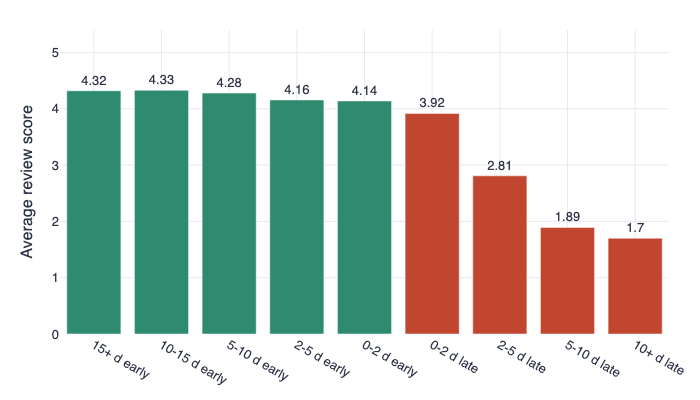

In [4]:
V.fig_delay_damage(A.delay_curve(base))

This is the most useful chart in the project, and it says two separate things.

**Look at the left half.** Delivering fifteen days early scores **4.32**. Delivering two days
early scores **4.14**. Thirteen extra days of speed buys essentially nothing. Once an order
is comfortably inside its promise, the customer has stopped caring, which means any
investment aimed at making already-fast deliveries faster is wasted money.

**Now the right half.** Two days late is survivable at **3.92**. Five-to-ten days late
collapses to **1.89**. Ten or more days late lands at **1.70**. The damage is concentrated
almost entirely in the tail.

Together those point somewhere quite specific: **the goal is not to reduce average delivery
time, it is to eliminate the worst outcomes.** A programme that shaved a day off every
delivery in the country would achieve less than one that fixed the slowest 5%. That
reframing is worth more than any individual number on the chart, because it changes what you
would fund.

---
# 3. Whose delay is it?

The brief points at slow sellers. That is the intuitive culprit: a seller sits on an order
for a week and the customer suffers. It is also, conveniently, the lever the marketplace
directly controls, which is probably why it is the one being reached for.

We can test it, because notebook 01 split the journey into stages that each belong to
somebody: handling is the seller's, transit is the carrier's.

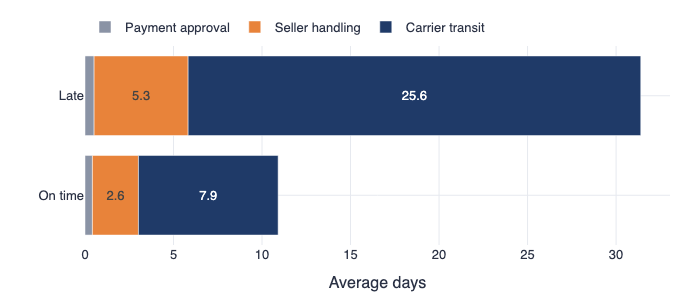

In [5]:
V.fig_journey(A.journey_stages(base))

In [6]:
corr = base[['review_score', 'handling_days', 'transit_days',
             'delivery_days', 'distance_km']].corr()['review_score'].round(3)
print(corr.drop('review_score').to_string())
print()
print(f"Seller handling, mean : {base.handling_days.mean():.1f} days")
print(f"Carrier transit, mean : {base.transit_days.mean():.1f} days")

handling_days   -0.159
transit_days    -0.301
delivery_days   -0.334
distance_km     -0.060

Seller handling, mean : 2.8 days
Carrier transit, mean : 9.3 days


This is the result that changed how we saw the whole project.

Sellers hand parcels to the carrier in **2.8 days** on average. The carrier then holds them
for **9.3 days**. On orders that end up late, the seller contributes 5.3 extra days and the
carrier contributes 25.6.

The correlations point the same way: **-0.16** for seller handling against **-0.30** for
carrier transit. The carrier holds the parcel more than three times as long and matters
about twice as much to the outcome.

So the lever in the brief (crack down on slow sellers) is aimed at the smaller half of the
problem. Not a useless lever, but not the main one, and the distinction is worth real money,
because coaching sellers and renegotiating carrier contracts are entirely different
programmes with entirely different budgets.

We were deliberately cautious about this finding, because it is *convenient*: it is the kind
of contrarian result that sounds clever in a presentation, and that is exactly when a claim
deserves the most scrutiny. Section 6 goes looking for evidence from a source that has
nothing to do with delivery timestamps.

Brazil is large, so before blaming carriers outright it is worth asking how much of the
transit time is simply distance.

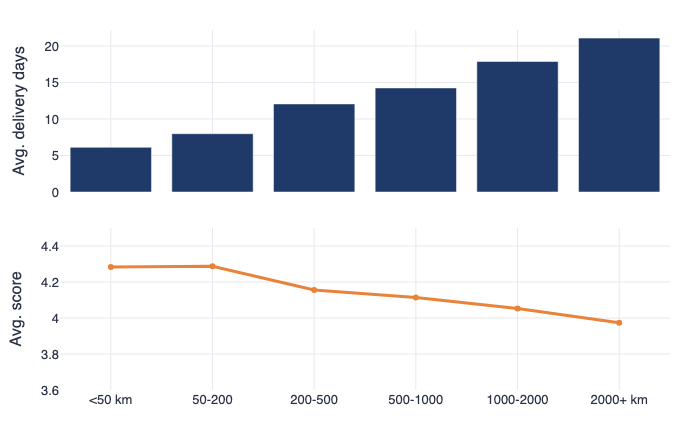

In [7]:
V.fig_distance(A.basket_effects(base))

Distance explains a lot of the *time* and much less of the *score*. Orders travelling over
2,000 km take roughly three and a half times as long as local ones, but their average score
falls by only about a third of a star. Its direct correlation with the review score is
**-0.06**, the weakest of anything we tested.

Read alongside the damage curve, that makes sense and is quietly good news: customers are
not angry about distance, they are angry about *broken promises*. A long delivery that
arrives when it was said to is fine. Distance only hurts when it turns into lateness, which
means the problem is addressable without moving any warehouses.

---
# 4. Is the promise itself part of the problem?

Every order carries an estimated delivery date, quoted at checkout, and lateness is measured
against *that*, not against any objective standard. So the promise is not a passive
measurement: it is a lever, and one the marketplace sets unilaterally.

The median order is promised in 23 days and arrives in 10. Thirteen days of apparent
sandbagging looks like an obvious thing to trim, and trimming it would make the checkout
page more competitive at no operational cost whatsoever. This section works out how much
slack is genuinely spare.

In [8]:
promise = A.promise_analysis(base)
promise.nlargest(12, 'orders')[
    ['customer_state', 'orders', 'median_promised', 'median_actual',
     'p92_actual', 'padding_days', 'safe_trim_days', 'late_rate']
].round(1)

,customer_state,orders,median_promised,median_actual,p92_actual,padding_days,safe_trim_days,late_rate
25,SP,40171,18.7,7.2,17.0,11.5,1.7,0.1
18,RJ,12172,24.6,12.0,31.9,12.6,0.0,0.1
10,MG,11251,23.6,10.3,21.4,13.3,2.2,0.1
22,RS,5309,28.0,13.2,28.0,14.8,0.0,0.1
17,PR,4880,24.0,10.4,21.3,13.6,2.8,0.0
23,SC,3510,25.1,13.0,27.4,12.1,0.0,0.1
4,BA,3226,29.0,16.9,33.2,12.1,0.0,0.1
6,DF,2064,24.1,11.4,22.9,12.7,1.1,0.1
7,ES,1966,25.0,13.6,27.0,11.5,0.0,0.1
8,GO,1939,27.0,13.9,26.1,13.0,0.9,0.1


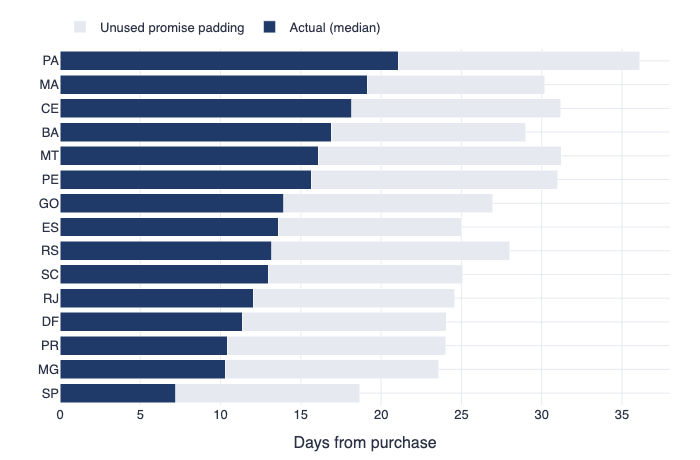

In [9]:
V.fig_promise_gap(promise)

`padding_days` is the gap between the promise and the typical delivery. `safe_trim_days` is
the honest version of it: how much could be cut while still covering 92% of orders in that
state, roughly today's on-time rate.

The two columns are nothing alike. São Paulo carries 11.5 days of apparent padding and only
**1.7** of it is genuinely spare. Rio de Janeiro, Rio Grande do Sul and Santa Catarina show
**zero** safe trim: their promise is already being used almost in full by their own worst
deliveries.

The padding is not waste. It is variance cover. The median order does not need it, but the
92nd-percentile order does, and the 92nd-percentile order is precisely the one sitting on the
cliff in section 2. Trim the promise and those orders do not get slower; they simply get
*reclassified as late*, and the cliff does the rest.

That is a genuine surprise. Going in, the expectation was that the quoted ETA was
sandbagged and tightening it was free. It is not free, and notebook 03 puts a number on how
expensive it is.

---
# 5. Where is the risk concentrated?

Now the Satisfaction-at-Risk metric from notebook 01 earns its keep. Every segment below is
ranked by excess detractors (how many one- and two-star reviews would vanish if it merely
behaved like the marketplace average) rather than by its raw score.

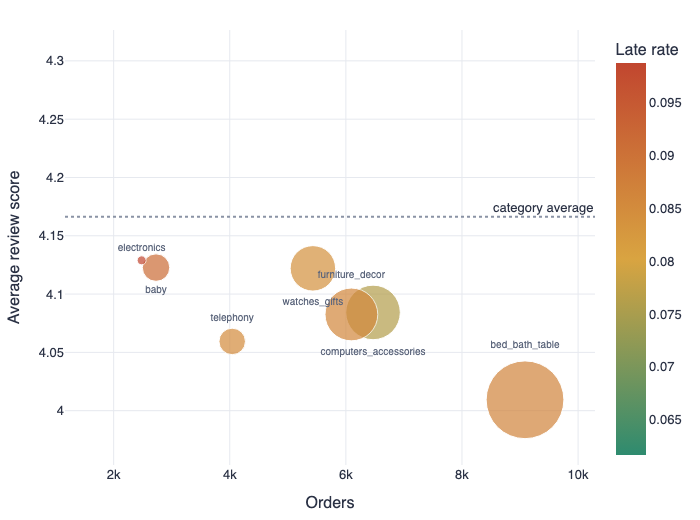

In [10]:
cat = A.category_view(base, baseline)
V.fig_category_risk(cat)

In [11]:
cat.nlargest(8, 'gmv_exposure')[
    ['main_category', 'orders', 'avg_score', 'bad_rate', 'late_rate',
     'excess_detractors', 'gmv_exposure']
].round(3)

,main_category,orders,avg_score,bad_rate,late_rate,excess_detractors,gmv_exposure
7,bed_bath_table,9086,4.009,0.158,0.087,271.293,30270.198
57,office_furniture,1236,3.652,0.218,0.091,111.969,24016.792
15,computers_accessories,6468,4.084,0.145,0.076,109.022,14897.816
39,furniture_decor,6095,4.083,0.148,0.086,121.713,13940.611
73,watches_gifts,5432,4.122,0.137,0.084,48.482,10328.550
72,unknown,1347,4.042,0.165,0.088,49.777,6300.841
6,baby,2730,4.123,0.137,0.091,25.951,3770.075
70,telephony,4042,4.059,0.139,0.085,46.203,3510.859


The bottom-right of that chart is the danger zone: high volume, below-average score.

**bed_bath_table** sits there and is the single largest exposure in the catalogue, not
because it is the worst-rated, but because it is large, slightly bad and slow all at once.
**office_furniture** is the worst category by score, but it is small enough that fixing it
moves less goodwill than fixing bed/bath/table would.

This is the ranking that a league table sorted by average score would get exactly backwards,
and it is the difference between a work list that helps and one that looks rigorous while
achieving very little.

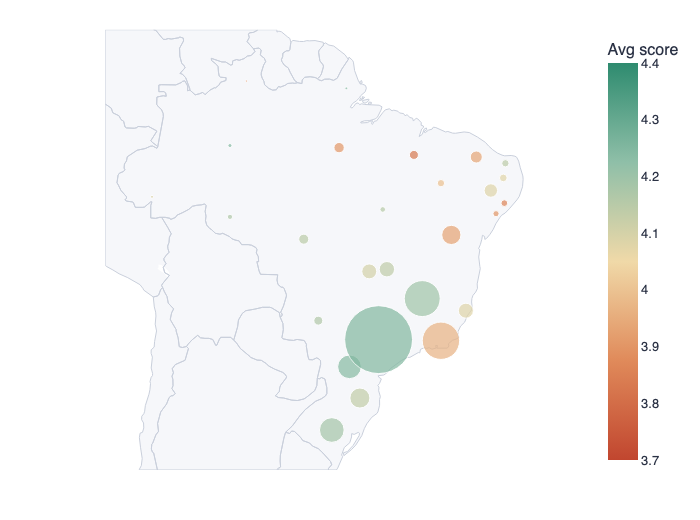

In [12]:
state = A.state_view(base, baseline)
V.fig_state_map(state)

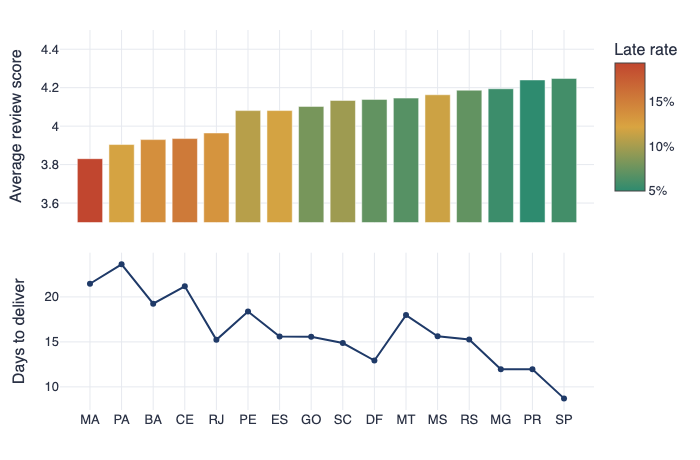

In [13]:
V.fig_state_bars(state)

The regional spread is wider than we expected. Maranhão averages **3.83** with a 19% late
rate and 21 days to deliver; São Paulo averages **4.25** with 6% late and under 9 days. Same
marketplace, same promise, completely different experience.

But the state we would actually escalate is **Rio de Janeiro**, and it does not look
alarming on either chart: 3.96 is mid-table. It is the second-largest market in the country
at 12,172 orders, and it runs **more than twice** São Paulo's late rate (13.3% against 5.8%).
Volume times a bad rate is where the damage lives, and Rio has both: on the SAR ranking in
notebook 01 it produced 678 excess detractors, more than the next five states combined.
Maranhão is worse per order, but there are only 709 of them.

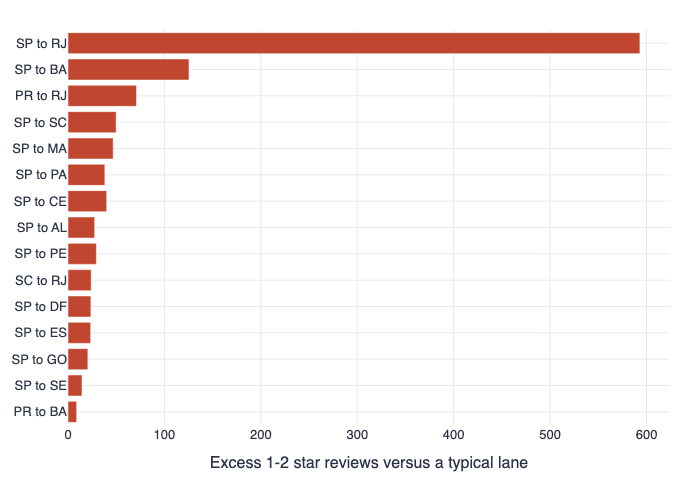

In [14]:
lane = A.lane_view(base, baseline)
V.fig_lane_risk(lane)

Lanes are where this gets operational. A state is not something anyone can fix; an
origin-destination pair is: it is a contract, a route and a depot.

**São Paulo to Rio de Janeiro** is the worst lane in the marketplace by a wide margin, and it
is not a remote-corridor problem: it is the busiest commercial route in the country,
running between two neighbouring states. Whatever is wrong there is a fixable operational
fault rather than an unavoidable consequence of Brazilian geography.

That single lane is the most concrete recommendation this project produces, and notebook 03
prices what fixing it would be worth.

---
# 6. Structural effects: the cheap fixes hide here

Everything so far needs a logistics budget. Before accepting that, it is worth checking the
structural properties of an order: how many sellers filled it, how it was paid for, how much
freight cost relative to the goods. These cost nothing to change compared with renegotiating
a carrier contract.

In [15]:
eff = A.basket_effects(base)
for dim in ['Sellers in order', 'Items in order', 'Cross-state shipment']:
    print(f'--- {dim} ---')
    print(eff[eff.dimension == dim][
        ['level', 'orders', 'avg_score', 'bad_rate', 'late_rate', 'avg_delivery_days']
    ].round(3).to_string(index=False))
    print()

--- Sellers in order ---
level  orders  avg_score  bad_rate  late_rate  avg_delivery_days
    1   94302      4.174     0.123      0.081             12.543
    2    1199      2.881     0.466      0.014              9.158
    3      59      2.237     0.644      0.000              8.380

--- Items in order ---
level  orders  avg_score  bad_rate  late_rate  avg_delivery_days
    1   86061      4.214     0.112      0.082             12.581
    2    7300      3.688     0.254      0.065             11.750
    3    1281      3.536     0.291      0.061             11.521
    4     485      3.361     0.346      0.054             12.074
    5     433      3.363     0.335      0.067             11.944

--- Cross-state shipment ---
          level  orders  avg_score  bad_rate  late_rate  avg_delivery_days
Different state   61168      4.096     0.141      0.091             15.078
     Same state   34392      4.266     0.104      0.060              7.908



In [16]:
for dim in ['Freight ratio quintile', 'Payment type', 'Installments']:
    print(f'--- {dim} ---')
    print(eff[eff.dimension == dim][
        ['level', 'orders', 'avg_score', 'bad_rate', 'late_rate', 'avg_delivery_days']
    ].round(3).to_string(index=False))
    print()

--- Freight ratio quintile ---
          level  orders  avg_score  bad_rate  late_rate  avg_delivery_days
(-0.001, 0.115]   19112      4.204     0.123      0.081             11.448
 (0.115, 0.183]   19112      4.178     0.123      0.079             11.967
 (0.183, 0.274]   19112      4.165     0.123      0.075             12.270
 (0.274, 0.435]   19122      4.127     0.135      0.083             13.054
   (0.435, 3.0]   19102      4.111     0.135      0.083             13.751

--- Payment type ---
      level  orders  avg_score  bad_rate  late_rate  avg_delivery_days
     boleto   19013      4.157     0.125      0.088             13.434
credit_card   72126      4.156     0.129      0.079             12.288
 debit_card    1475      4.243     0.110      0.079             10.749
    voucher    2946      4.128     0.135      0.070             12.472

--- Installments ---
level  orders  avg_score  bad_rate  late_rate  avg_delivery_days
    0       2      5.000     0.000      0.000          

**Split shipments are the find of the notebook.** An order filled by one seller averages
**4.17**. Split it across two and it drops to **2.88**. Three or more and it is **2.24**.

The mechanism makes sense once you picture it. The customer ordered one thing, a basket,
and it arrives in pieces over several days. They wait for the slowest parcel, and then they
review *the whole order* on that experience. One slow seller poisons the entire basket.

What makes it the best finding here is the ratio: it costs **1.3 stars** and it affects only
**1.3% of orders**. Everything else in this notebook needs a logistics budget. This one needs
either consolidated fulfilment or simply a clearer checkout that sets expectations per
parcel, so the customer mentally scores three deliveries instead of one bad one. We would
genuinely have missed it if we had not been checking a variable we assumed was irrelevant.

The other dimensions are mostly negative results, which are still worth stating: payment
type and instalment count barely move the score, so there is no evidence that payment
friction drives dissatisfaction. Freight ratio matters a little at the extremes. Cross-state
shipment carries a real penalty, but section 3 already told us that is distance turning into
lateness rather than an effect of its own.

---
# 7. An independent check on the delivery story

Section 3 concluded the carrier owns most of the delay. That conclusion drives an expensive
recommendation, so before notebook 03 attaches money to it we want evidence from a source
that is not the delivery timestamps.

41% of reviews carry a written comment. They are in Portuguese, nobody has read them, and
they were produced by the customers themselves rather than by any operational system. That
makes them about as independent a witness as this dataset offers.

In [17]:
themes = pd.read_csv(C.TABLE_DIR / 'review_themes.csv')
themes.round(3)

,theme,mentions,share_of_negative_comments,late_share_within_theme
0,Delivery / lateness,5166,0.477,0.413
1,Never arrived,2825,0.261,0.632
2,Refund or service,1713,0.158,0.255
3,Wrong or missing item,1544,0.143,0.102
4,Product quality,995,0.092,0.191
5,Damaged or defective,589,0.054,0.058


**48% of negative comments mention delivery. 26% say the order never turned up at all.**
Product quality, the thing you would assume drives a one-star review, is 9%.

That is the confirmation we wanted: two independent sources, structured timestamps and
unstructured Portuguese text, pointing at the same conclusion. We are now comfortable
recommending a logistics investment.

One thing worth not glossing over: **16% of complaints are about refunds and service
response.** No amount of faster shipping touches those. It is a smaller problem than
delivery but it is a real one, and it belongs to a different team entirely.

Themes are assigned by keyword matching, which is a blunt instrument: it can only find
what it was told to look for. As a guard against that, the table below asks the data which
words actually distinguish a bad review from a good one, without being told anything in
advance.

In [18]:
terms = pd.read_csv(C.TABLE_DIR / 'review_terms.csv')
terms.nlargest(15, 'z')[['term', 'gloss', 'z', 'n_bad', 'n_good']]

,term,gloss,z,n_bad,n_good
0,recebi,I received,41.396873,2992.0,1428.0
1,comprei,I bought,35.738384,1778.0,567.0
2,agora,NaN,22.673959,666.0,158.0
3,pedido,order,19.947358,746.0,370.0
4,apenas,only,19.684105,525.0,148.0
5,veio,came,19.226036,1366.0,1111.0
6,contato,contact,18.622319,450.0,53.0
7,dois,NaN,18.361157,443.0,111.0
8,aguardando,waiting,18.095143,421.0,53.0
9,dia,NaN,17.614782,623.0,331.0


The ranking is by weighted log-odds with a Dirichlet prior, not by raw frequency. The
distinction matters: raw counts would just return the most common words in Portuguese, and
comparing plain proportions would let a word appearing three times in five reviews outrank a
word appearing four hundred times in a thousand. The prior shrinks exactly those
small-sample terms toward zero, so what survives to the top is both distinctive *and*
well-evidenced.

And the answer is unambiguous. The top of the list is **`recebi` ("I received")** by a wide
margin, then `comprei` ("I bought"), `pedido` ("order"), `contato` ("contact"), `aguardando`
and `aguardo` ("waiting" / "I await"), and `paguei` ("I paid").

Read them together and the grammar is as telling as the vocabulary. These are
first-person past-tense verbs (*I bought, I paid, I received*), which in a one-star review
are almost always carrying a negation or a complaint about what came back: I bought and it
never arrived, I paid and I am still waiting. Two of the fifteen are literally the verb
"to wait", and `contato` is a customer reporting they had to chase somebody.

Notably absent from the top of the list: any word about the product itself: quality,
defect, broken, wrong. Those words exist in the corpus, but they are not what separates a
one-star review from a five-star one.

This is a genuinely independent confirmation, arrived at without touching a single
timestamp, and it lands on the same conclusion as section 3.

---
# 8. What we carry into notebook 03

- **Growth is not visibly costing satisfaction in aggregate**, which is why the segment
  work was necessary rather than optional.
- **The damage curve is a cliff, not a slope.** Target the worst outcomes, not the average.
- **The carrier owns roughly twice as much of the problem as the seller**, confirmed
  independently by the review text.
- **The promise padding is variance cover, not waste.** Most of it cannot be trimmed
  without manufacturing lateness.
- **The risk concentrates in nameable places**: the São Paulo-Rio lane, Rio de Janeiro as a
  market, bed/bath/table as a category.
- **Split shipments cost 1.3 stars on 1.3% of orders**, the cheapest fix available.

Notebook 03 turns these into decisions: a model to see whether a bad review can be
predicted early enough to intervene, a verdict for every seller, and a price tag on each
option.